In [30]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_equations import Newt_Rap

import lib_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Newton's Method: Pathological Cases**

Write a function that implements Newton’s algorithm and study the following three cases, which should illustrate the problems of this method.

---

### 1. Slow convergence

Consider the function  $f(x) = x^2$ and calculate its root using the Newton–Raphson algorithm, starting from $x_0 = 0.8$. Is the convergence quadratic?  
Explain this using both **analytical** and **numerical** evidence.

---

### 2. Cycles

In some cases the Newton method never converges: due to a conspiracy between the function and the starting guess, the algorithm enters an endless loop.
Consider the function $f(x) = x^3 - 2x + 2$ and the starting guesses $x_0 = 0 \quad \text{and} \quad x_0 = 1$.

Plot the values of the root $x_n$ as a function of $n$.  
Why is the method oscillating between 0 and 1?

Once the mechanism is understood, find a solution.

---

### 3. Initial conditions

Newton’s algorithm may be very susceptible to initial conditions, in particular if we choose a starting guess (or if we end up sitting on a point) where the first derivative is very close to zero.

This can lead to a large jump in one iteration that sends the algorithm to a region closer to a different solution with respect to the one we were tackling.


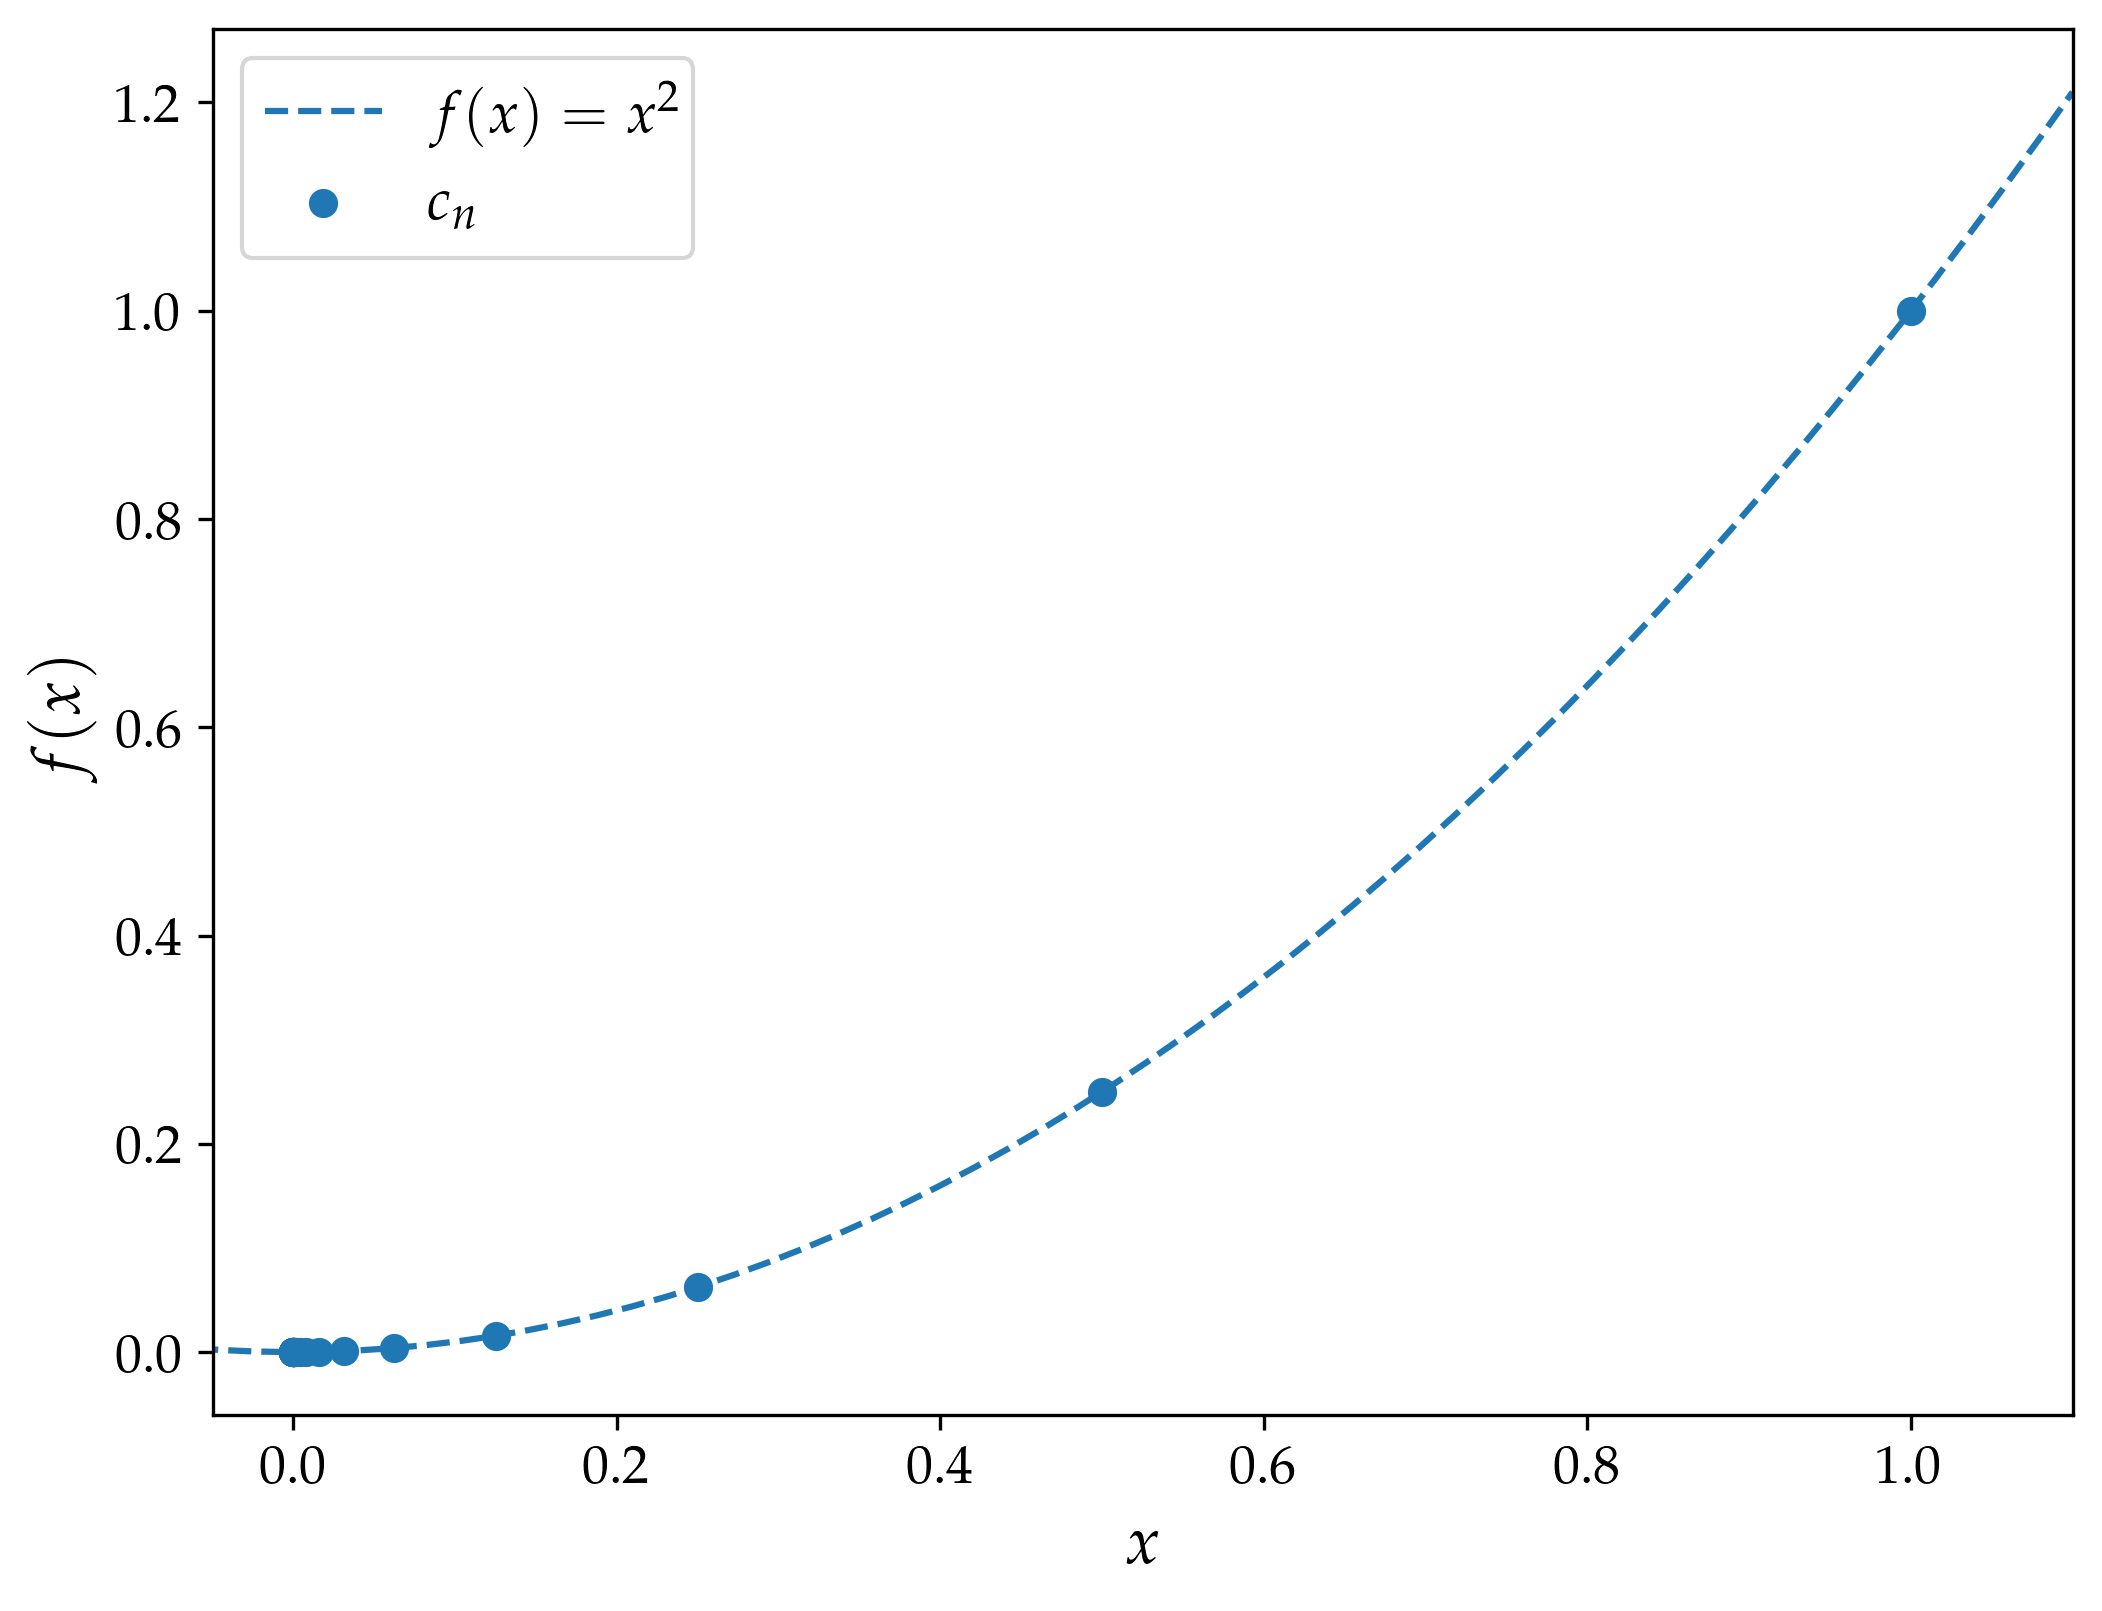

In [31]:
x_sp = sp.symbols('x')
sp_f = x_sp**2
sp_der = sp.simplify(sp.diff(sp_f, x_sp))

f_lamb = sp.lambdify(x_sp, sp_f, 'numpy')
derf_lamb = sp.lambdify(x_sp, sp_der, 'numpy')

c, num_iter, sol_arr = Newt_Rap(f_lamb, derf_lamb, 1)

xcoo = np.linspace(-1, 1.1, 100)
ycoo = np.array([f_lamb(i) for i in xcoo])
y_sp = np.real(np.array([f_lamb(i) for i in sol_arr]))

plt.plot(xcoo, ycoo, ls='--', label=r'$f(x) = x^2$')
plt.scatter(np.real(sol_arr), y_sp, label='$c_n$')
plt.xlabel(r'$x$')
plt.ylabel(r'$f(x)$')
plt.xlim(-0.05, 1.1)
plt.legend()
plt.savefig('plots/init_cond.png')
plt.show()


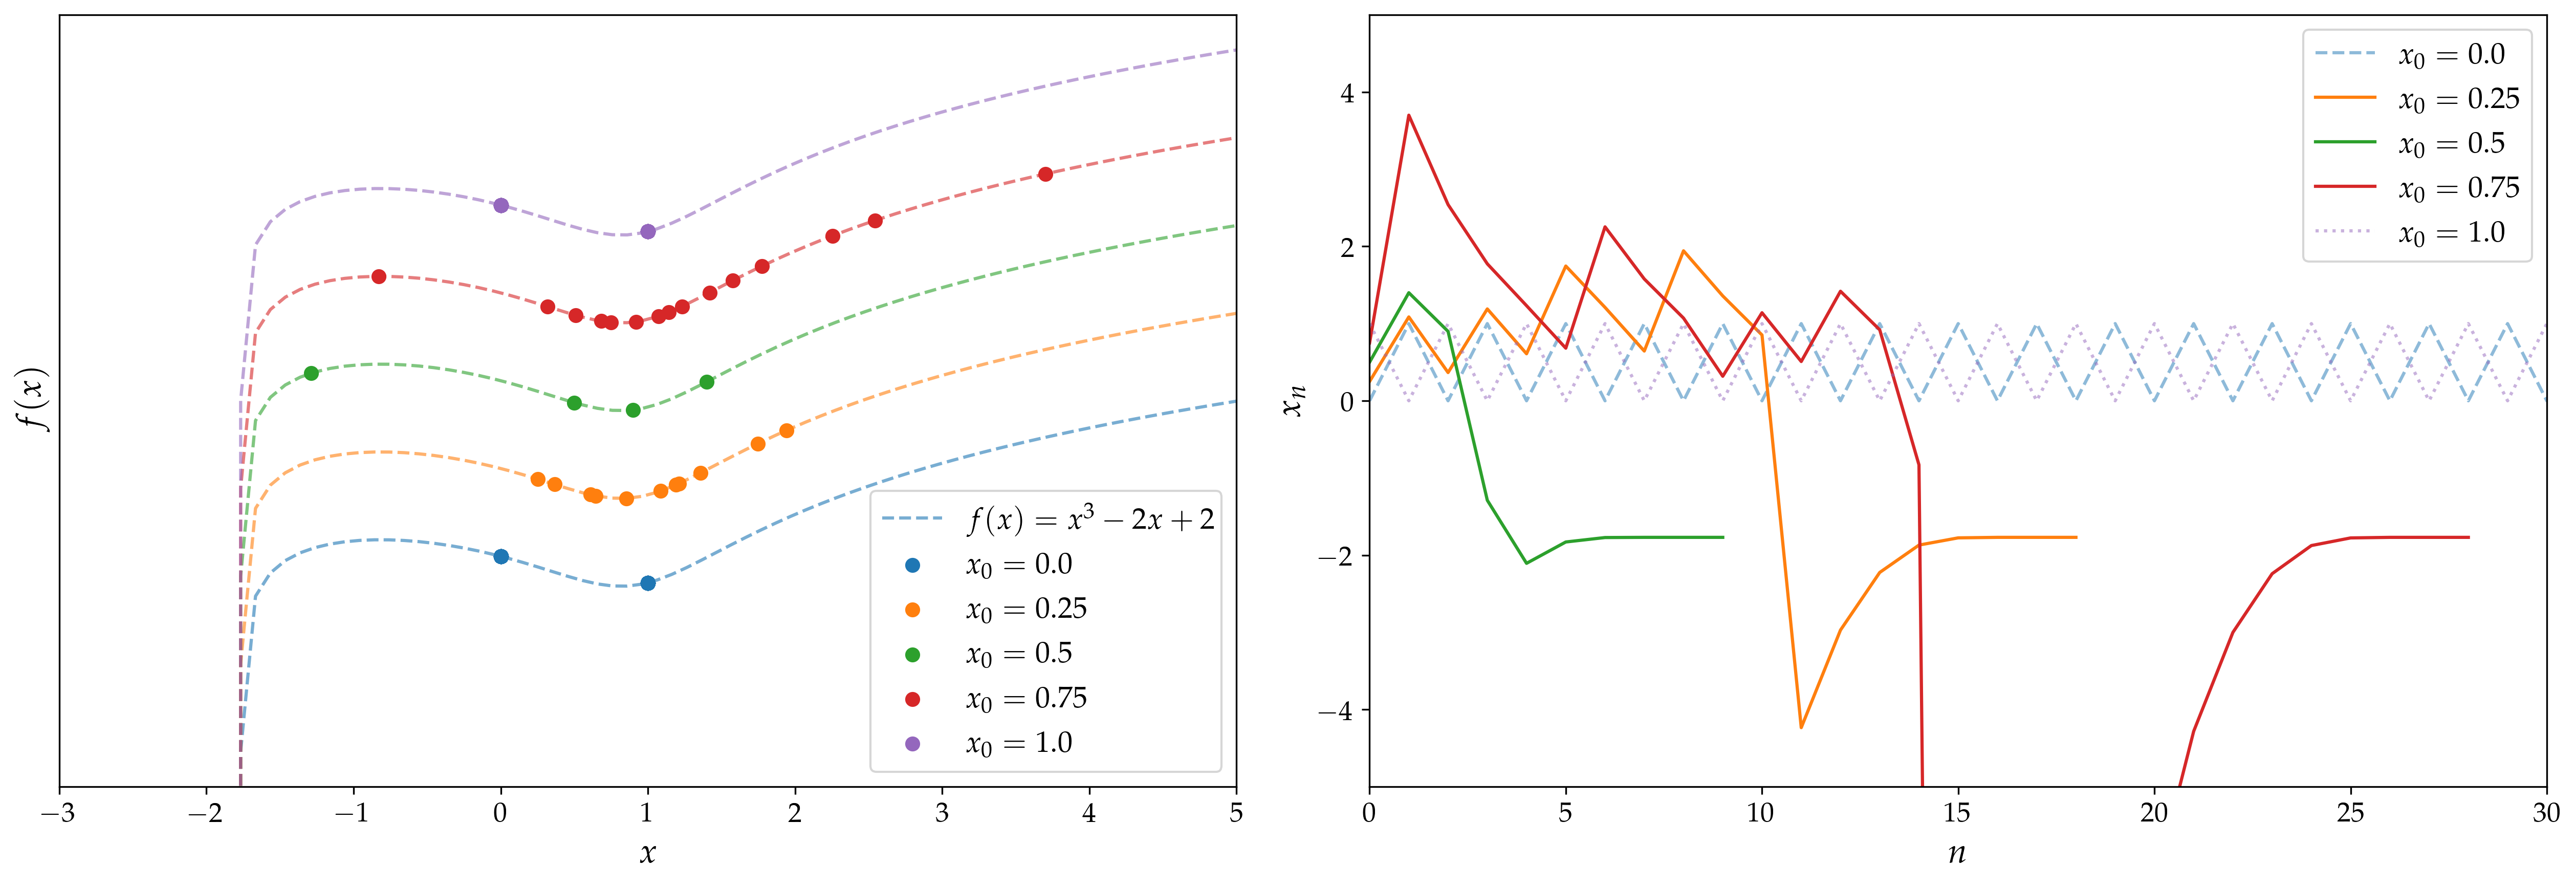

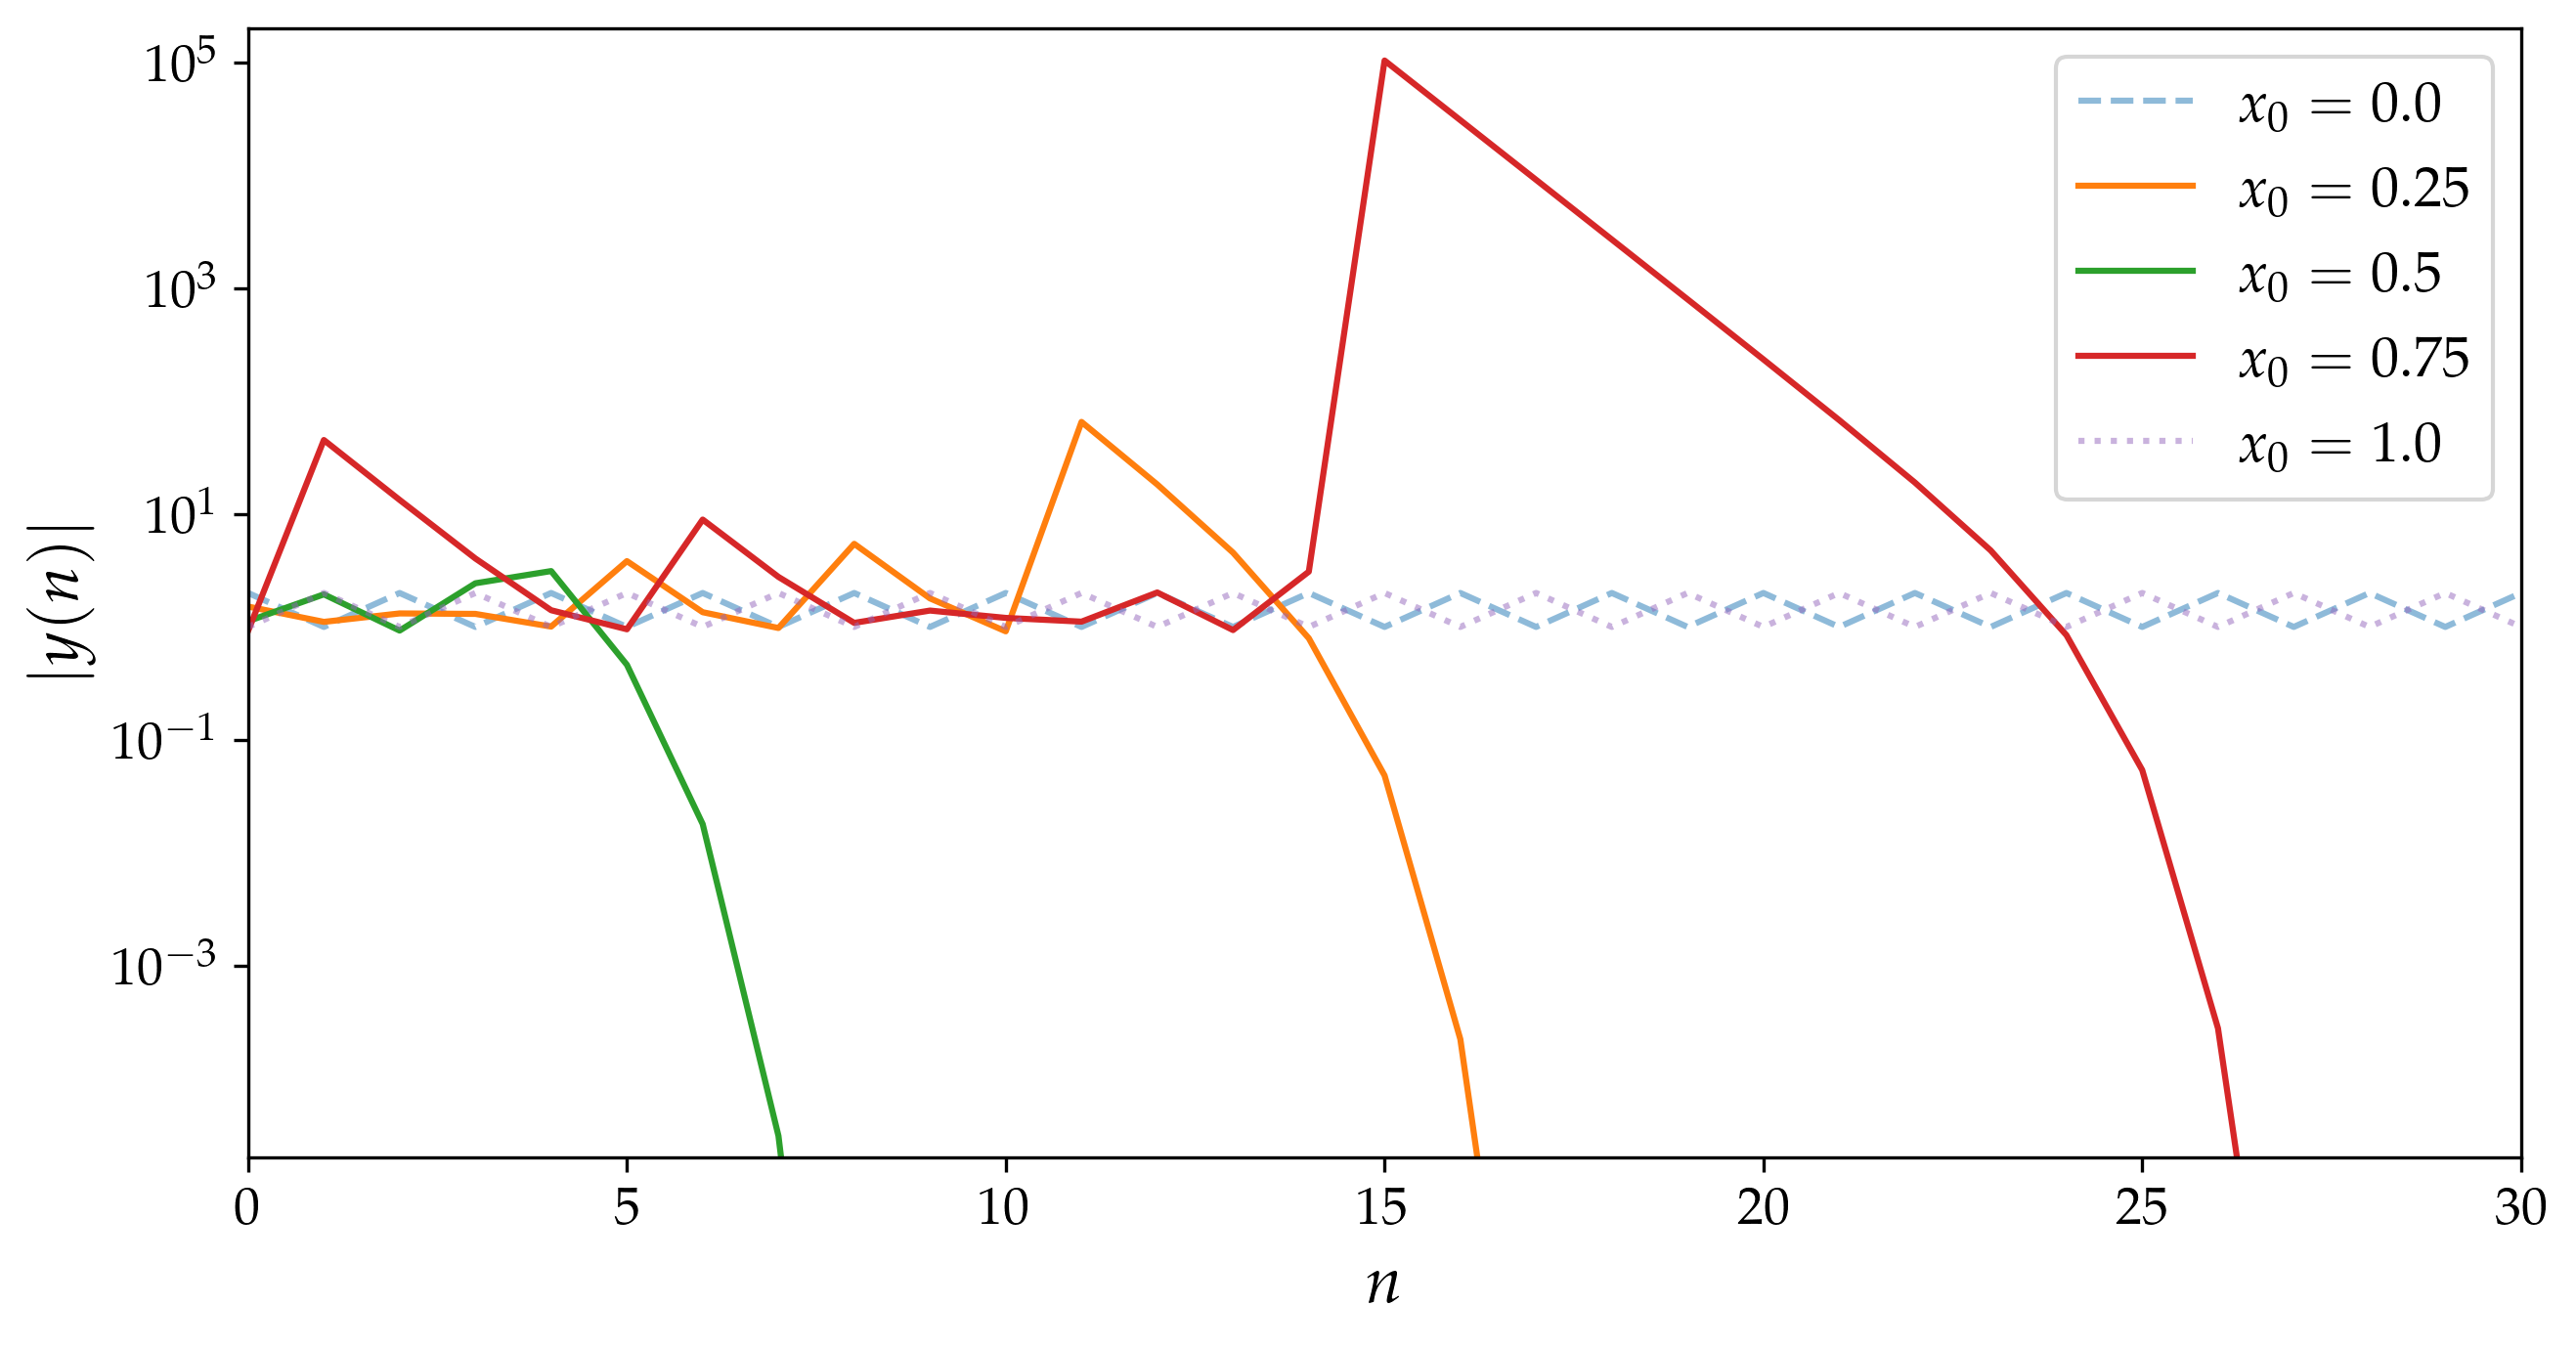

In [32]:
def plot_Newt_Rap(sp_func, sp_x, x0, tol=1e-14, MaxIter=1e2):
    import sympy as sp
    # we consider sp_func defined in terms of sympy and 1-dim, in the variable sp_x
    sp_der = sp.simplify(sp.diff(sp_func, sp_x))
    f_lamb = sp.lambdify(sp_x, sp_func, 'numpy')
    derf_lamb = sp.lambdify(sp_x, sp_der, 'numpy')

    xn = x0
    f_val = f_lamb(xn)
    f_der_val = derf_lamb(xn)
    x1 = x0 - f_val / f_der_val
    n_iter = 1

    sol_ls = []
    sol_ls.append(x0)
    sol_ls.append(x1)

    while abs(complex(sp_func.subs(sp_x, x1))) > tol and n_iter<MaxIter:
        f_val = f_lamb(x1)
        f_der_val = derf_lamb(x1)
        x_next = lambda x_old: x_old - f_val / f_der_val    
        
        if f_der_val == 0:
            raise ValueError("Derivative is 0. Newton would break.")
        x0 = x1
        x1 = x_next(x0)
        sol_ls.append(x1)
        n_iter += 1
    return x1, n_iter, np.array(sol_ls)

x_sp = sp.symbols('x')
sp_f = x_sp**3 - 2*x_sp + 2
lamb_f = sp.lambdify(x_sp, sp_f, 'numpy')

xcoo = np.linspace(-5, 5, 100)
ycoo = np.array([lamb_f(i) for i in xcoo])
y_max, y_min = 1, -1

fig, ax = plt.subplots(1,2, figsize=(17, 6))
ax[0].plot(xcoo, ycoo, ls='--', label=r'$f(x) = x^3 - 2x + 2$', alpha=0.6)

fig_err, ax_err = plt.subplots(figsize=(10, 5))
for n, x_init in enumerate(np.linspace(0, 1, 5)):
    c0, num_iter0, sol_arr0 = plot_Newt_Rap(sp_f, x_sp, x_init)
    y_sp0 = np.real(np.array([lamb_f(i) for i in sol_arr0]))*10**n
    y_max, y_min = (max(y_max, max(y_sp0)), min(y_min, min(y_sp0)))
    ycoo = np.array([lamb_f(i) for i in xcoo])*10**n
    
    if n != 0:
        ax[0].plot(xcoo, ycoo, ls='--', alpha=0.6)
    ax[0].scatter(np.real(sol_arr0), y_sp0, label=rf'$x_0 = {x_init}$')

    x_iter = np.arange(num_iter0+1)
    yerr = np.abs(lamb_f(sol_arr0))
    if n==0:
        ax[1].plot(x_iter, sol_arr0, alpha=0.5, label=rf'$x_0 = {x_init}$', ls='--')
        ax_err.plot(x_iter, yerr, alpha=0.5, label=rf'$x_0 = {x_init}$', ls='--')
    elif n==4:
        ax[1].plot(x_iter, sol_arr0, alpha=0.5, label=rf'$x_0 = {x_init}$', ls=':')
        ax_err.plot(x_iter, yerr, alpha=0.5, label=rf'$x_0 = {x_init}$', ls=':')
    else:
        ax[1].plot(x_iter, sol_arr0, label=rf'$x_0 = {x_init}$')        
        ax_err.plot(x_iter, yerr, label=rf'$x_0 = {x_init}$')

ax[0].set_xlim(-3, 5)
ax[1].set_xlim(0, 30)
ax[1].set_ylim(-5, 5)

ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$f(x)$')
ax[1].set_xlabel(r'$n$')
ax[1].set_ylabel(r'$x_n$')

import matplotlib.ticker as ticker
ax[0].set_yscale('log')
ax[0].yaxis.set_major_locator(ticker.NullLocator())
ax[0].yaxis.set_minor_locator(ticker.NullLocator())
ax[0].legend()
ax[1].legend()

ax_err.set_xlim(0, 30)
ax_err.set_ylim(2e-5, 2e5)
ax_err.set_xlabel(r'$n$')
ax_err.set_ylabel(r'$|y(n)|$')
ax_err.set_yscale('log')
ax_err.legend()
fig.tight_layout()
fig.savefig('plots/fn_plot.png')
fig_err.savefig('plots/err_n.png')
plt.show()


## **Complex Function zeros**

In [33]:
z_sp = sp.symbols('z')
sp_fz = (z_sp**2 - 1)*(z_sp**2 + 1)

fz = sp.lambdify(z_sp, sp_fz, 'numpy')
der_fz = sp.lambdify(z_sp, sp.simplify(sp.diff(sp_fz, z_sp)), 'numpy')

N = 3000
x = np.linspace(-1,1,N).astype(np.float64)
X, Y = np.meshgrid(x, x)
z_init = X + 1j*Y

c_mat = Newt_Rap(fz, der_fz, z_init,tol=1e-6, MaxIter=50)


c:\Users\Marco\Desktop\Marco\coding\Lab_comp\lib_equations.py:20: RuntimeWarning: 
Maximum iterations reached. Algorithm diverges!
  n_iter = 0


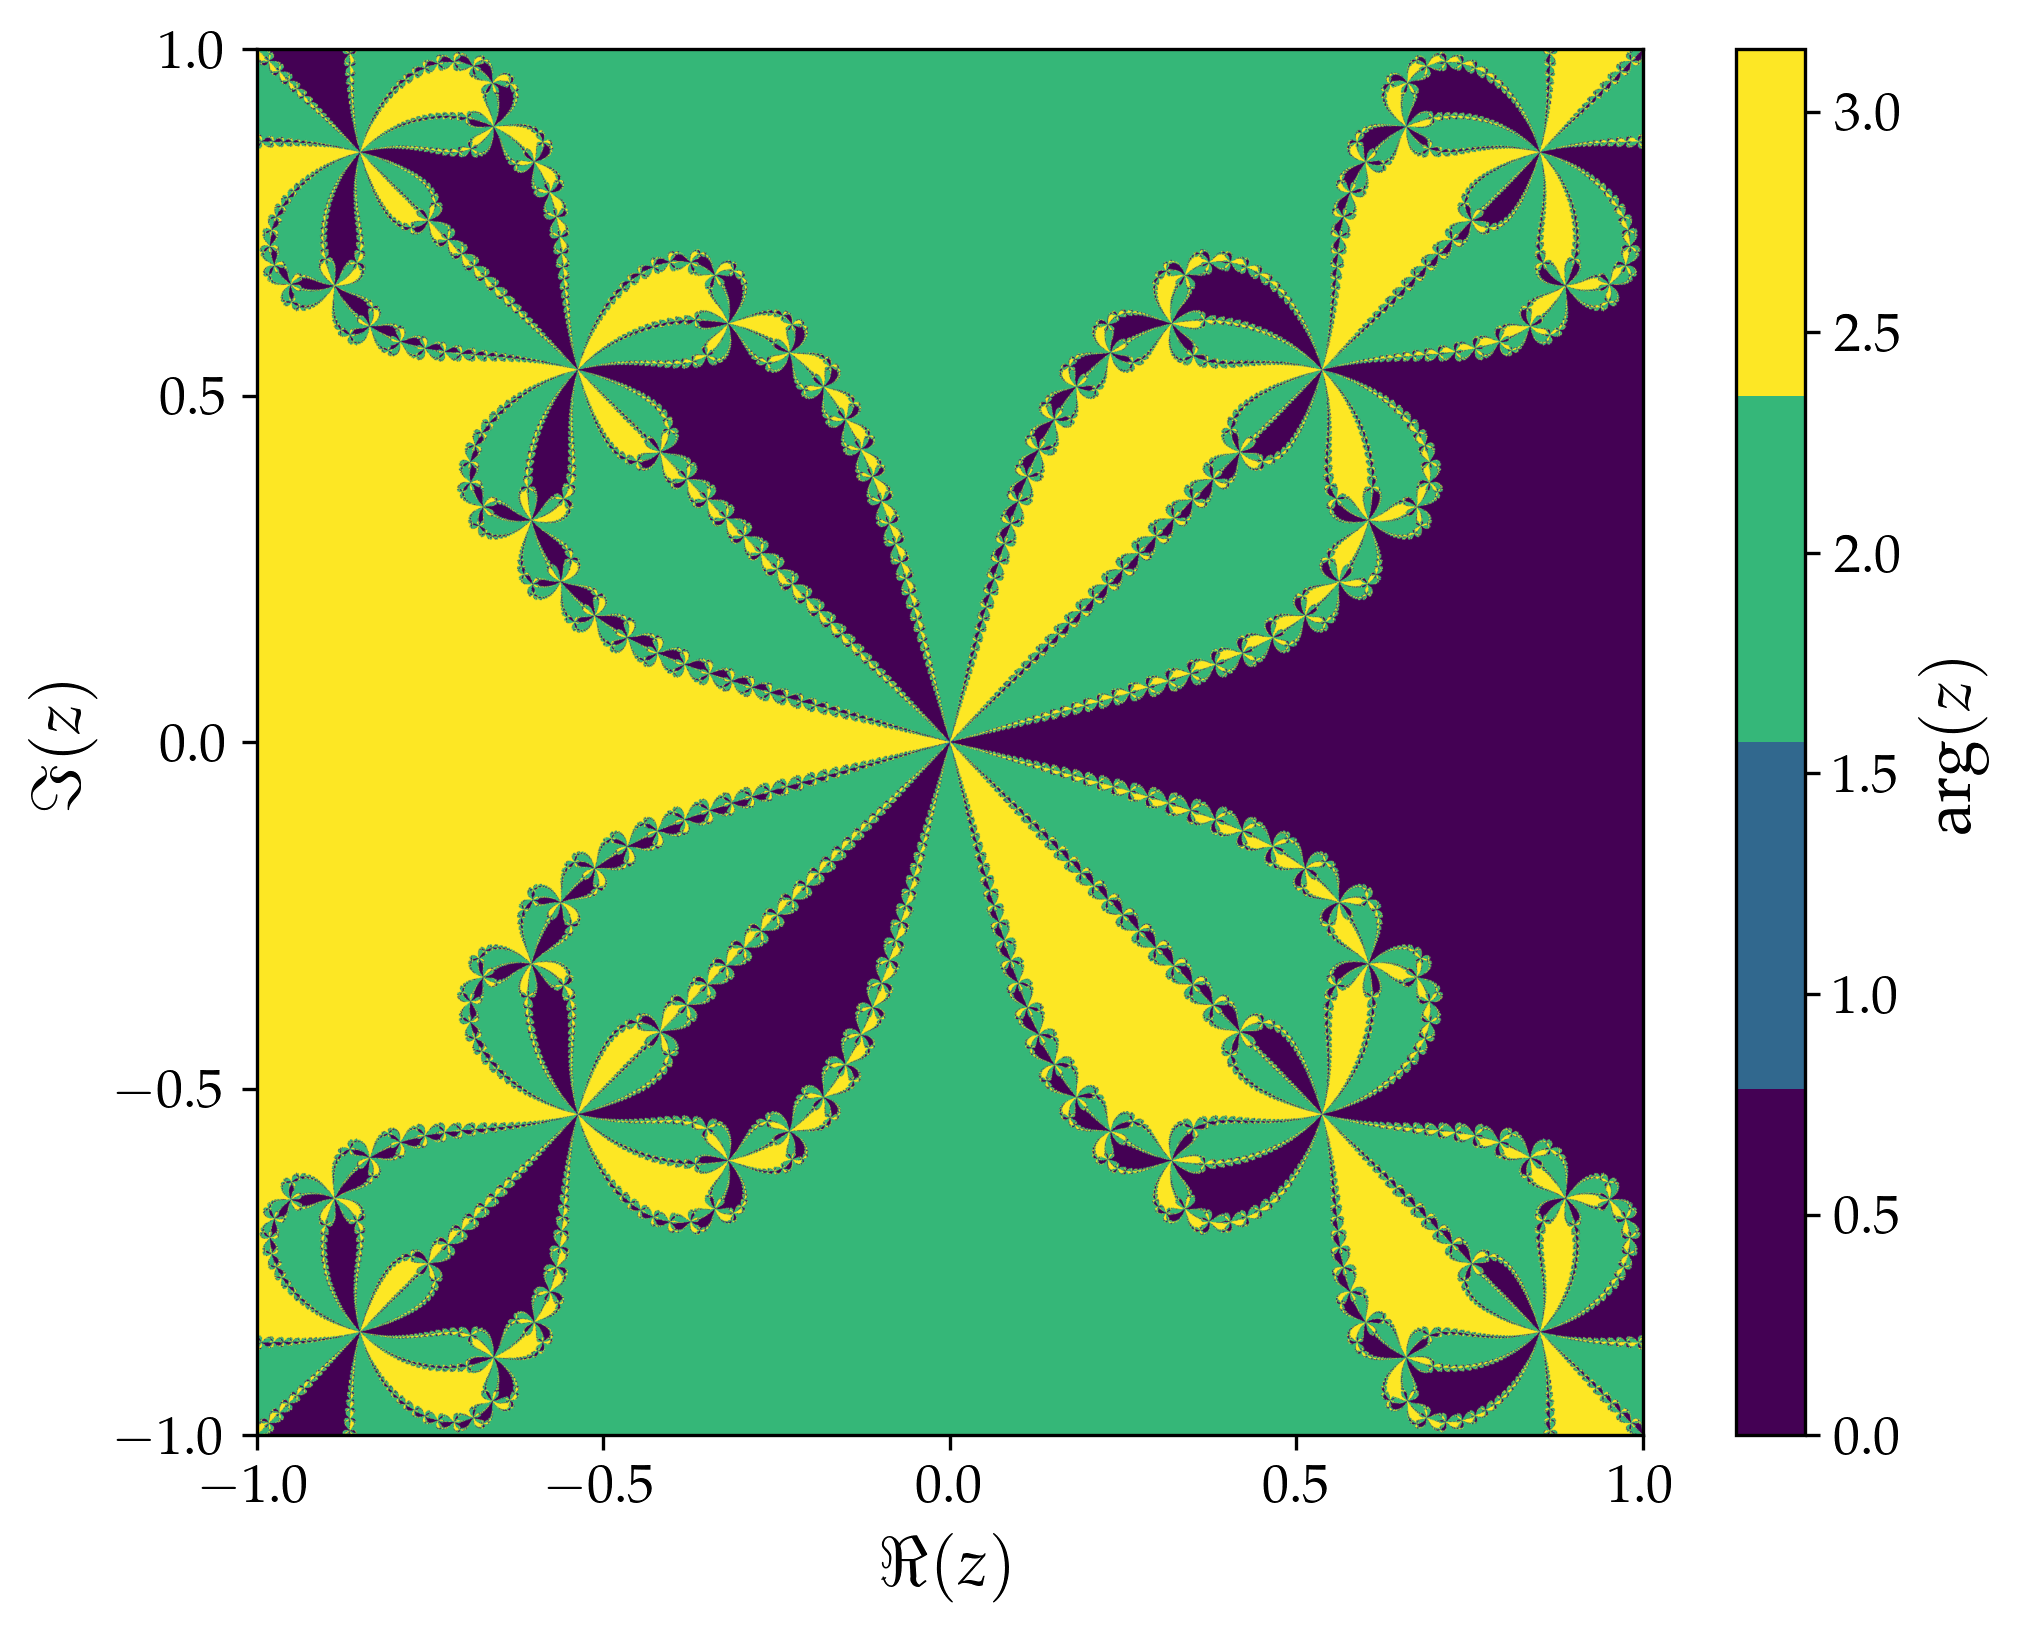

In [ ]:
c_angle = abs(np.angle(c_mat))
c_angle = np.round(c_angle, 4)
cmap_discreta = plt.get_cmap("viridis", 4)
plt.imshow(c_angle, cmap=cmap_discreta, extent=[-1, 1, -1, 1])
cbar = plt.colorbar()
cbar.set_label(r'$\arg(z)$')

plt.xticks([-1, -0.5, 0, 0.5, 1])
plt.yticks([-1, -0.5, 0, 0.5, 1])
plt.xlabel(r'$\Re(z)$')
plt.ylabel(r'$\Im(z)$')

plt.savefig('plots/fractal.png')
plt.show()